In [25]:
#importing the essential libraries, pandas for analysis and matplotlib for data visualization

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#importing the data set

df = pd.read_csv("student-mat.csv")

#inspection
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [28]:
#the following data looks messy because the function read_csv doesn't recognise semicolons
#as the default separators so it lumps everything into a single column, to fix this we use the following:

df = pd.read_csv("student-mat.csv", sep = ";")

#inspection
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [29]:
#cleaning the data for further use

#checking for missing values
print(df.isnull().sum())

#isnull functions checks for NaN values if there is a NaN value then it replaces that column with 1 or true and false or 0 for vice versa.
#this essentailly creates a giant table with 1s and 0s which is not very visually appealing.
#so we use the sum() to add all the values of that attribute, and the total of those values tells us the number of missing values
#so if the total is 5 then there are 5 missing values conversly if the total is 0 then there are no missing values

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [30]:
#checking for duplicates
print(df.duplicated().sum())
#it identifies duplicates and updates the dataframe

0


In [31]:
#inspecting:
#shape: the size of the table
print(df.shape)

#the data type for each attribute
print(df.dtypes)

(395, 33)
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [32]:
#finding the average of grade (G3)
average_g3 = df['G3'].mean()
print("Average Final Grade: ", round(average_g3,2))

Average Final Grade:  10.42


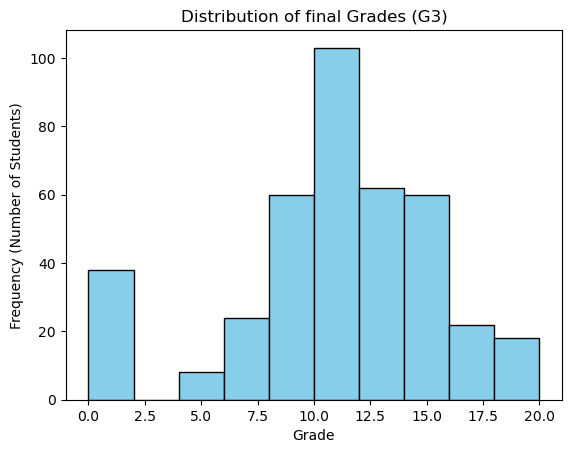

In [33]:
#creating a histogram for grades
plt.hist(df['G3'], bins = 10, color = 'skyblue', edgecolor = 'black')
plt.title("Distribution of final Grades (G3)")
plt.xlabel("Grade")
plt.ylabel("Frequency (Number of Students)")
plt.show()

In [34]:
#to find the number of students who score above 15
high_scores = df[df['G3']>15]
count_high_scores = len(high_scores)
print(f"Number of Students who scored above 15: {count_high_scores}")

Number of Students who scored above 15: 40


In [35]:
#to show the correlation of study time with performance
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation of study time with performance: {correlation:.2f}")
#since the value is above 0 we can conclude that there is atleast some positive impact

Correlation of study time with performance: 0.10


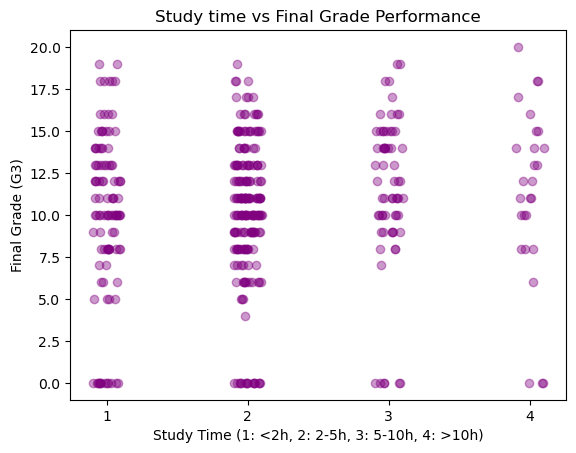

In [36]:
#creating a scatter plot for better visual representation
if 'studytime' in df.columns:
    jitter = np.random.uniform(-0.1, 0.1, size=len(df))

    plt.scatter(df['studytime'] + jitter, df['G3'], alpha=0.4, color='purple')
    plt.title("Study time vs Final Grade Performance")
    plt.xlabel("Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)")
    plt.ylabel("Final Grade (G3)")
    plt.xticks([1, 2, 3, 4])
    plt.show()
else:
    print("Column 'studytime' not found. Available columns are:", df.columns.tolist())

    #since the study time is given in a range, we use jittering so the dots don't overlap on each other

In [38]:
#to find out which gender performs better on average

gender_performance = df.groupby('sex')['G3'].mean()
print(gender_performance)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


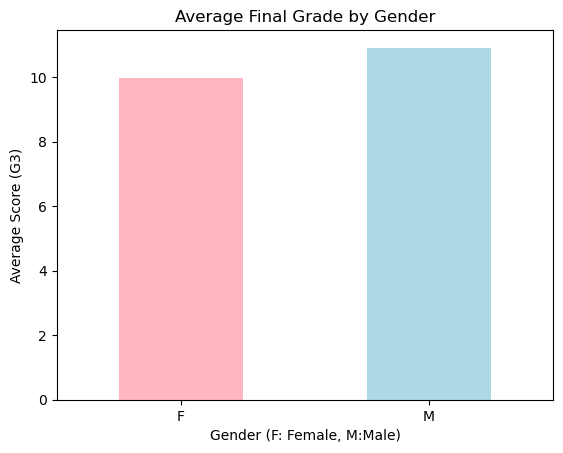

In [39]:
#plotting a bar graph for better visual representation
gender_performance.plot(kind='bar',color=['lightpink','lightblue'])
plt.title("Average Final Grade by Gender")
plt.xlabel("Gender (F: Female, M:Male)")
plt.ylabel("Average Score (G3)")
plt.xticks(rotation=0)
plt.show()